In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 84.2 MB/s eta 0:00:00


In [ ]:
!uv pip install -q datasets huggingface_hub
!uv pip install -q torch torchvision torchaudio
!uv pip install -q scikit-learn pandas matplotlib seaborn
!uv pip install -q tqdm scipy


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models
from torchvision import transforms

from datasets import load_dataset
from huggingface_hub import HfApi, login, create_repo

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from scipy import stats

from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Check GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB

✅ Using device: cuda


In [ ]:
login()

In [ ]:
# Enable TF32 for faster training on A100
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

## 2. Load and Explore Datasets

In [ ]:
print("Loading real dataset...")
real_dataset = load_dataset("hf-vision/chest-xray-pneumonia")

print("\nLoading synthetic dataset...")
synthetic_dataset = load_dataset("chimbiwide/synthetic-chest-xray-pneumonia")

print("\n" + "="*60)
print("REAL DATASET STRUCTURE")
print("="*60)
print(real_dataset)

print("\n" + "="*60)
print("SYNTHETIC DATASET STRUCTURE")
print("="*60)
print(synthetic_dataset)

Loading real dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/446M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/68.9M [00:00<?, ?B/s]

...

data/train-00001-of-00002.parquet:   0%|          | 0.00/355M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/79.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2160 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/240 [00:00<?, ? examples/s]


REAL DATASET STRUCTURE
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5216
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 16
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 624
    })
})

SYNTHETIC DATASET STRUCTURE
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2160
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 240
    })
})


In [ ]:
# ============================================================
# CELL 5: Analyze Dataset Dimensions
# ============================================================
def analyze_dimensions(dataset, split_name, dataset_name):
    """Analyze image dimensions in a dataset split."""
    dimensions = []
    for sample in tqdm(dataset[split_name], desc=f"Analyzing {dataset_name}/{split_name}"):
        w, h = sample['image'].size
        dimensions.append((w, h))

    dim_counts = Counter(dimensions)
    print(f"\n{dataset_name} - {split_name}:")
    print(f"  Total images: {len(dimensions)}")
    print(f"  Unique dimensions: {len(dim_counts)}")
    print(f"  Most common dimensions:")
    for dim, count in dim_counts.most_common(5):
        print(f"    {dim[0]}×{dim[1]}: {count} images")
    return dim_counts

# Analyze real dataset
print("="*60)
print("DIMENSION ANALYSIS")
print("="*60)

real_train_dims = analyze_dimensions(real_dataset, 'train', 'Real')
real_test_dims = analyze_dimensions(real_dataset, 'test', 'Real')

# Analyze synthetic dataset (check available splits)
synth_splits = list(synthetic_dataset.keys())
print(f"\nSynthetic dataset splits: {synth_splits}")
for split in synth_splits:
    analyze_dimensions(synthetic_dataset, split, 'Synthetic')

DIMENSION ANALYSIS


Analyzing Real/train:   0%|          | 0/5216 [00:00<?, ?it/s]


Real - train:
  Total images: 5216
  Unique dimensions: 4366
  Most common dimensions:
    1072×648: 7 images
    1080×728: 6 images
    1008×680: 5 images
    976×672: 5 images
    1216×872: 5 images


Analyzing Real/test:   0%|          | 0/624 [00:00<?, ?it/s]


Real - test:
  Total images: 624
  Unique dimensions: 598
  Most common dimensions:
    1112×736: 3 images
    2517×1979: 2 images
    1304×952: 2 images
    1168×824: 2 images
    1368×904: 2 images

Synthetic dataset splits: ['train', 'test']


Analyzing Synthetic/train:   0%|          | 0/2160 [00:00<?, ?it/s]


Synthetic - train:
  Total images: 2160
  Unique dimensions: 1
  Most common dimensions:
    512×512: 2160 images


Analyzing Synthetic/test:   0%|          | 0/240 [00:00<?, ?it/s]


Synthetic - test:
  Total images: 240
  Unique dimensions: 1
  Most common dimensions:
    512×512: 240 images


In [ ]:
# ============================================================
# CELL 6: Check Label Distribution
# ============================================================
def check_label_distribution(dataset, split_name, dataset_name):
    """Check class distribution."""
    labels = [sample['label'] for sample in dataset[split_name]]
    label_counts = Counter(labels)

    print(f"\n{dataset_name} - {split_name}:")
    for label, count in sorted(label_counts.items()):
        label_name = 'NORMAL' if label == 0 else 'PNEUMONIA'
        print(f"  {label_name} (label={label}): {count} images")
    return label_counts

print("="*60)
print("LABEL DISTRIBUTION")
print("="*60)

real_train_labels = check_label_distribution(real_dataset, 'train', 'Real')
real_test_labels = check_label_distribution(real_dataset, 'test', 'Real')

for split in synthetic_dataset.keys():
    check_label_distribution(synthetic_dataset, split, 'Synthetic')

LABEL DISTRIBUTION

Real - train:
  NORMAL (label=0): 1341 images
  PNEUMONIA (label=1): 3875 images

Real - test:
  NORMAL (label=0): 234 images
  PNEUMONIA (label=1): 390 images

Synthetic - train:
  NORMAL (label=0): 1080 images
  PNEUMONIA (label=1): 1080 images

Synthetic - test:
  NORMAL (label=0): 120 images
  PNEUMONIA (label=1): 120 images


## 3. Dataset and Model Classes

In [ ]:
# ============================================================
# CELL 7: Define Transforms
# ============================================================
# Using Resize + CenterCrop to handle varying dimensions properly
# This preserves aspect ratio and keeps the centered lung region

def get_transforms(train=True, target_size=224):
    """
    Get image transforms with proper aspect ratio handling.
    Uses Resize (shortest edge) + CenterCrop to avoid distortion.

    Args:
        train: Whether to apply training augmentations
        target_size: Final image size (default 224 for DenseNet)
    """
    # Resize shortest edge to slightly larger than target, then center crop
    resize_size = int(target_size * 1.14)  # ~256 for target_size=224

    if train:
        return transforms.Compose([
            transforms.Resize(resize_size),           # Shortest edge = resize_size
            transforms.CenterCrop(target_size),       # Square crop from center
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(resize_size),           # Shortest edge = resize_size
            transforms.CenterCrop(target_size),       # Square crop from center
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

print(" Transforms defined")
print(f"   Training: Resize(256) → CenterCrop(224) → Augmentations → Normalize")
print(f"   Validation: Resize(256) → CenterCrop(224) → Normalize")

✅ Transforms defined
   Training: Resize(256) → CenterCrop(224) → Augmentations → Normalize
   Validation: Resize(256) → CenterCrop(224) → Normalize


In [ ]:
# ============================================================
# CELL 8: Define Custom Dataset Class
# ============================================================
class ChestXrayDataset(Dataset):
    """Custom dataset for chest X-rays with synthetic data support."""

    def __init__(
        self,
        real_dataset=None,
        real_split='train',
        synthetic_dataset=None,
        synthetic_split='train',
        real_ratio: float = 1.0,
        synthetic_ratio: float = 0.0,
        transform=None,
        seed: int = 42
    ):
        """
        Args:
            real_dataset: HuggingFace dataset for real images
            real_split: Split to use from real dataset
            synthetic_dataset: HuggingFace dataset for synthetic images
            synthetic_split: Split to use from synthetic dataset
            real_ratio: Fraction of real images to use (0.0 to 1.0)
            synthetic_ratio: Fraction of synthetic images to use (0.0 to 1.0)
            transform: Image transformations
            seed: Random seed for reproducible subsampling
        """
        self.samples = []  # List of (image, label, source)
        self.transform = transform

        np.random.seed(seed)

        # Add real images
        if real_dataset is not None and real_ratio > 0:
            real_data = real_dataset[real_split]
            num_real = len(real_data)
            num_samples = int(num_real * real_ratio)

            indices = np.random.permutation(num_real)[:num_samples]

            for idx in indices:
                sample = real_data[int(idx)]
                self.samples.append({
                    'image': sample['image'],
                    'label': sample['label'],
                    'source': 'real'
                })

        # Add synthetic images
        if synthetic_dataset is not None and synthetic_ratio > 0:
            synth_data = synthetic_dataset[synthetic_split]
            num_synth = len(synth_data)
            num_samples = int(num_synth * synthetic_ratio)

            indices = np.random.permutation(num_synth)[:num_samples]

            for idx in indices:
                sample = synth_data[int(idx)]
                self.samples.append({
                    'image': sample['image'],
                    'label': sample['label'],
                    'source': 'synthetic'
                })

        # Shuffle combined dataset
        np.random.shuffle(self.samples)

        # Count by source and label
        real_count = sum(1 for s in self.samples if s['source'] == 'real')
        synth_count = sum(1 for s in self.samples if s['source'] == 'synthetic')
        normal_count = sum(1 for s in self.samples if s['label'] == 0)
        pneumonia_count = sum(1 for s in self.samples if s['label'] == 1)

        print(f"Dataset created: {len(self.samples)} total images")
        print(f"  Sources: {real_count} real, {synth_count} synthetic")
        print(f"  Labels: {normal_count} normal, {pneumonia_count} pneumonia")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = sample['image']

        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, sample['label']

print("ChestXrayDataset class defined")

✅ ChestXrayDataset class defined


In [ ]:
class PneumoniaClassifier(nn.Module):
    """DenseNet-121 based classifier for pneumonia detection."""

    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        # Load pretrained DenseNet-121
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        self.densenet = models.densenet121(weights=weights)

        # Replace classifier head
        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.densenet(x)

def count_parameters(model):
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Test model
test_model = PneumoniaClassifier()
print(f"PneumoniaClassifier defined")
print(f"   Trainable parameters: {count_parameters(test_model):,}")
del test_model

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 236MB/s]


✅ PneumoniaClassifier defined
   Trainable parameters: 7,479,682


## 4. Training Functions

In [ ]:
def train_classifier(
    model,
    train_loader,
    val_loader,
    num_epochs=5,
    learning_rate=5e-5,
    device='cuda',
    save_path='best_model.pth',
    verbose=True
):
    """Train the pneumonia classifier."""

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'val_acc': [], 'val_f1': [], 'val_auc': [],
        'val_precision': [], 'val_recall': []
    }

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
                          disable=not verbose, leave=False)

        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_loss /= len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]",
                                       disable=not verbose, leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())

        val_loss /= len(val_loader)

        # Calculate metrics
        val_acc = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='binary', zero_division=0
        )
        try:
            auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            auc = 0.0

        # Log history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(f1)
        history['val_auc'].append(auc)
        history['val_precision'].append(precision)
        history['val_recall'].append(recall)

        if verbose:
            print(f"Epoch {epoch+1:2d}: Loss={train_loss:.4f}/{val_loss:.4f}, "
                  f"Acc={val_acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_f1': f1,
                'val_auc': auc,
            }, save_path)
            if verbose:
                print(f"  ✓ Saved best model (acc={val_acc:.4f})")

        scheduler.step()

    return history, best_val_acc

print("Training function defined")

✅ Training function defined


In [ ]:
def evaluate_model(model, test_loader, device='cuda'):
    """Evaluate model on test set and return detailed metrics."""

    model = model.to(device)
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    # Calculate all metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary', zero_division=0
    )
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    cm = confusion_matrix(all_labels, all_preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

print("Evaluation function defined")

✅ Evaluation function defined


## 5. Experiment Configuration

In [ ]:
# Training configuration
CONFIG = {
    'batch_size': 256,
    'num_workers': 0,
    'learning_rate': 1e-4,
    'num_epochs': 20,
    'seeds': [123],
    'device': DEVICE,
}

# Experiment definitions
EXPERIMENTS = {
    'baseline': {
        'real_ratio': 1.0,
        'synthetic_ratio': 0.0,
        'description': '100% real, 0% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-baseline'
    },
    'synth25': {
        'real_ratio': 1.0,
        'synthetic_ratio': 0.25,
        'description': '100% real, 25% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-synth25'
    },
    'synth50': {
        'real_ratio': 1.0,
        'synthetic_ratio': 0.50,
        'description': '100% real, 50% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-synth50'
    },
    'synth100': {
        'real_ratio': 1.0,
        'synthetic_ratio': 1.0,
        'description': '100% real, 100% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-synth100'
    },
    'limited10': {
        'real_ratio': 0.10,
        'synthetic_ratio': 1.0,
        'description': '10% real, 100% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-limited10'
    },
    'limited25': {
        'real_ratio': 0.25,
        'synthetic_ratio': 1.0,
        'description': '25% real, 100% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-limited25'
    },
    'synthonly': {
        'real_ratio': 0.0,
        'synthetic_ratio': 1.0,
        'description': '0% real, 100% synthetic',
        'hf_model_name': 'chimbiwide/pneumonia-densenet-synthonly'
    },
}

print("Experiment configurations defined")
print(f"\nTotal experiments: {len(EXPERIMENTS)}")
print(f"Runs per experiment: {len(CONFIG['seeds'])}")
print(f"Total models to train: {len(EXPERIMENTS) * len(CONFIG['seeds'])}")
print(f"Models to upload: {len(EXPERIMENTS)} (best from each experiment)")

✅ Experiment configurations defined

Total experiments: 7
Runs per experiment: 1
Total models to train: 7
Models to upload: 7 (best from each experiment)


In [ ]:
import os

OUTPUT_DIR = './experiment_results'
MODELS_DIR = f'{OUTPUT_DIR}/models'
PLOTS_DIR = f'{OUTPUT_DIR}/plots'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"   Output directories created:")
print(f"   Results: {OUTPUT_DIR}")
print(f"   Models: {MODELS_DIR}")
print(f"   Plots: {PLOTS_DIR}")

✅ Output directories created:
   Results: ./experiment_results
   Models: ./experiment_results/models
   Plots: ./experiment_results/plots


In [ ]:
test_dataset = ChestXrayDataset(
    real_dataset=real_dataset,
    real_split='test',
    synthetic_dataset=None,
    real_ratio=1.0,
    synthetic_ratio=0.0,
    transform=get_transforms(train=False),
    seed=42
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print(f"\nTest DataLoader created with {len(test_dataset)} images")

Dataset created: 624 total images
  Sources: 624 real, 0 synthetic
  Labels: 234 normal, 390 pneumonia

✅ Test DataLoader created with 624 images


## 6. Run All Experiments

In [ ]:
# Determine synthetic split name
synth_split = list(synthetic_dataset.keys())[0]  # Use first available split
print(f"Using synthetic split: '{synth_split}'")

all_results = {}

for exp_name, exp_config in EXPERIMENTS.items():
    print("\n" + "="*70)
    print(f"EXPERIMENT: {exp_name.upper()}")
    print(f"Description: {exp_config['description']}")
    print("="*70)

    exp_results = {
        'config': exp_config,
        'runs': [],
        'best_run': None,
        'best_accuracy': 0,
        'best_model_path': None
    }

    for seed_idx, seed in enumerate(CONFIG['seeds']):
        print(f"\n--- Run {seed_idx+1}/{len(CONFIG['seeds'])} (seed={seed}) ---")

        # Set seeds for reproducibility
        torch.manual_seed(seed)
        np.random.seed(seed)

        # Create training dataset
        train_dataset = ChestXrayDataset(
            real_dataset=real_dataset if exp_config['real_ratio'] > 0 else None,
            real_split='train',
            synthetic_dataset=synthetic_dataset if exp_config['synthetic_ratio'] > 0 else None,
            synthetic_split=synth_split,
            real_ratio=exp_config['real_ratio'],
            synthetic_ratio=exp_config['synthetic_ratio'],
            transform=get_transforms(train=True),
            seed=seed
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=CONFIG['batch_size'],
            shuffle=True,
            num_workers=CONFIG['num_workers'],
            pin_memory=True
        )

        # Initialize model
        model = PneumoniaClassifier(pretrained=True)

        # Model save path
        model_path = f"{MODELS_DIR}/{exp_name}_seed{seed}.pth"

        # Train
        history, best_acc = train_classifier(
            model=model,
            train_loader=train_loader,
            val_loader=test_loader,
            num_epochs=CONFIG['num_epochs'],
            learning_rate=CONFIG['learning_rate'],
            device=CONFIG['device'],
            save_path=model_path,
            verbose=True
        )

        # Load best model and evaluate
        checkpoint = torch.load(model_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        eval_results = evaluate_model(model, test_loader, device=CONFIG['device'])

        # Store run results
        run_result = {
            'seed': seed,
            'history': history,
            'eval_metrics': {
                'accuracy': eval_results['accuracy'],
                'precision': eval_results['precision'],
                'recall': eval_results['recall'],
                'f1': eval_results['f1'],
                'auc': eval_results['auc'],
                'confusion_matrix': eval_results['confusion_matrix']
            },
            'model_path': model_path
        }
        exp_results['runs'].append(run_result)

        print(f"\nRun {seed_idx+1} Final: Acc={eval_results['accuracy']:.4f}, "
              f"F1={eval_results['f1']:.4f}, AUC={eval_results['auc']:.4f}")

        # Track best run
        if eval_results['accuracy'] > exp_results['best_accuracy']:
            exp_results['best_accuracy'] = eval_results['accuracy']
            exp_results['best_run'] = seed_idx
            exp_results['best_model_path'] = model_path

        # Clean up
        del model, train_dataset, train_loader
        torch.cuda.empty_cache()

    # Calculate aggregate statistics
    accuracies = [r['eval_metrics']['accuracy'] for r in exp_results['runs']]
    f1_scores = [r['eval_metrics']['f1'] for r in exp_results['runs']]
    auc_scores = [r['eval_metrics']['auc'] for r in exp_results['runs']]

    exp_results['aggregate'] = {
        'accuracy_mean': np.mean(accuracies),
        'accuracy_std': np.std(accuracies),
        'f1_mean': np.mean(f1_scores),
        'f1_std': np.std(f1_scores),
        'auc_mean': np.mean(auc_scores),
        'auc_std': np.std(auc_scores),
        'all_accuracies': accuracies,
        'all_f1_scores': f1_scores,
        'all_auc_scores': auc_scores
    }

    all_results[exp_name] = exp_results

    print(f"\n{exp_name.upper()} SUMMARY:")
    print(f"  Accuracy: {exp_results['aggregate']['accuracy_mean']:.4f} \u00b1 {exp_results['aggregate']['accuracy_std']:.4f}")
    print(f"  F1 Score: {exp_results['aggregate']['f1_mean']:.4f} \u00b1 {exp_results['aggregate']['f1_std']:.4f}")
    print(f"  AUC: {exp_results['aggregate']['auc_mean']:.4f} \u00b1 {exp_results['aggregate']['auc_std']:.4f}")
    print(f"  Best run: seed={CONFIG['seeds'][exp_results['best_run']]}, acc={exp_results['best_accuracy']:.4f}")

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED!")
print("="*70)


Using synthetic split: 'train'

EXPERIMENT: BASELINE
Description: 100% real, 0% synthetic

--- Run 1/1 (seed=123) ---
Dataset created: 5216 total images
  Sources: 5216 real, 0 synthetic
  Labels: 1341 normal, 3875 pneumonia


Epoch 1/20 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch  1: Loss=0.2605/0.6097, Acc=0.7660, F1=0.8420, AUC=0.9305
  ✓ Saved best model (acc=0.7660)


Epoch 2/20 [Train]:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch 20/20 [Train]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch 20: Loss=0.0003/2.0399, Acc=0.6458, F1=0.7792, AUC=0.8370


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


Run 1 Final: Acc=0.7067, F1=0.8092, AUC=0.9042

SYNTHONLY SUMMARY:
  Accuracy: 0.7067 ± 0.0000
  F1 Score: 0.8092 ± 0.0000
  AUC: 0.9042 ± 0.0000
  Best run: seed=123, acc=0.7067

ALL EXPERIMENTS COMPLETED!


In [ ]:
# ============================================================
# CELL 16: Save All Results to JSON
# ============================================================

def convert_to_serializable(obj):
    """Convert numpy types to Python native types for JSON serialization."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    return obj

# Save results
results_path = f"{OUTPUT_DIR}/all_results.json"
with open(results_path, 'w') as f:
    json.dump(convert_to_serializable(all_results), f, indent=2)

print(f"Results saved to {results_path}")

✅ Results saved to ./experiment_results/all_results.json


## 7. Results Analysis

In [ ]:
def analyze_results(results):
    """Perform statistical analysis comparing all experiments to baseline."""

    baseline_accs = results['baseline']['aggregate']['all_accuracies']

    print("\n" + "="*90)
    print("STATISTICAL ANALYSIS - COMPARISON TO BASELINE")
    print("="*90)
    print(f"{'Experiment':<15} {'Accuracy':<20} {'F1 Score':<20} {'AUC':<20} {'vs Baseline':<15}")
    print("-"*90)

    analysis_data = []

    for exp_name, data in results.items():
        agg = data['aggregate']

        acc_str = f"{agg['accuracy_mean']:.4f} ± {agg['accuracy_std']:.4f}"
        f1_str = f"{agg['f1_mean']:.4f} ± {agg['f1_std']:.4f}"
        auc_str = f"{agg['auc_mean']:.4f} ± {agg['auc_std']:.4f}"

        if exp_name == 'baseline':
            delta_str = "(baseline)"
            p_value = 1.0
        else:
            delta = agg['accuracy_mean'] - results['baseline']['aggregate']['accuracy_mean']
            _, p_value = stats.ttest_ind(baseline_accs, agg['all_accuracies'])
            sig = "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
            delta_str = f"{delta:+.4f} (p={p_value:.3f}){sig}"

        print(f"{exp_name:<15} {acc_str:<20} {f1_str:<20} {auc_str:<20} {delta_str:<15}")

        analysis_data.append({
            'experiment': exp_name,
            'accuracy_mean': agg['accuracy_mean'],
            'accuracy_std': agg['accuracy_std'],
            'f1_mean': agg['f1_mean'],
            'f1_std': agg['f1_std'],
            'auc_mean': agg['auc_mean'],
            'auc_std': agg['auc_std'],
            'delta_vs_baseline': agg['accuracy_mean'] - results['baseline']['aggregate']['accuracy_mean'],
            'p_value': p_value,
            'significant_05': p_value < 0.05,
            'significant_01': p_value < 0.01
        })

    print("-"*90)
    print("* p < 0.05 (significant) | ** p < 0.01 (highly significant)")

    return pd.DataFrame(analysis_data)

analysis_df = analyze_results(all_results)

# Save analysis to CSV
analysis_df.to_csv(f"{OUTPUT_DIR}/statistical_analysis.csv", index=False)
print(f"\nAnalysis saved to {OUTPUT_DIR}/statistical_analysis.csv")


STATISTICAL ANALYSIS - COMPARISON TO BASELINE
Experiment      Accuracy             F1 Score             AUC                  vs Baseline    
------------------------------------------------------------------------------------------
baseline        0.8798 ± 0.0000      0.9117 ± 0.0000      0.9668 ± 0.0000      (baseline)     
synth25         0.8942 ± 0.0000      0.9216 ± 0.0000      0.9748 ± 0.0000      +0.0144 (p=nan)
synth50         0.9022 ± 0.0000      0.9269 ± 0.0000      0.9732 ± 0.0000      +0.0224 (p=nan)
synth100        0.8974 ± 0.0000      0.9236 ± 0.0000      0.9761 ± 0.0000      +0.0176 (p=nan)
limited10       0.8862 ± 0.0000      0.9150 ± 0.0000      0.9606 ± 0.0000      +0.0064 (p=nan)
limited25       0.8766 ± 0.0000      0.9095 ± 0.0000      0.9650 ± 0.0000      -0.0032 (p=nan)
synthonly       0.7067 ± 0.0000      0.8092 ± 0.0000      0.9042 ± 0.0000      -0.1731 (p=nan)
------------------------------------------------------------------------------------------
* p < 0.05 

In [ ]:
print("\n" + "="*70)
print("LIMITED DATA SCENARIO ANALYSIS")
print("="*70)

# Compare limited scenarios to what they'd be without synthetic data
# limited10 with synthetic vs baseline with 10% data (hypothetical)
# We compare to synthonly to see if real data helps

limited_10_acc = all_results['limited10']['aggregate']['accuracy_mean']
limited_25_acc = all_results['limited25']['aggregate']['accuracy_mean']
synth_only_acc = all_results['synthonly']['aggregate']['accuracy_mean']
baseline_acc = all_results['baseline']['aggregate']['accuracy_mean']

print(f"\nKey Comparisons:")
print(f"  Baseline (100% real):        {baseline_acc:.4f}")
print(f"  Synthetic Only (0% real):    {synth_only_acc:.4f}")
print(f"  Limited 10% + Synthetic:     {limited_10_acc:.4f}")
print(f"  Limited 25% + Synthetic:     {limited_25_acc:.4f}")

print(f"\nInsights:")
print(f"  Adding 10% real data to synthetic improves by: {limited_10_acc - synth_only_acc:+.4f}")
print(f"  Adding 25% real data to synthetic improves by: {limited_25_acc - synth_only_acc:+.4f}")
print(f"  Gap between limited10+synth and baseline: {limited_10_acc - baseline_acc:+.4f}")
print(f"  Gap between limited25+synth and baseline: {limited_25_acc - baseline_acc:+.4f}")


LIMITED DATA SCENARIO ANALYSIS

Key Comparisons:
  Baseline (100% real):        0.8798
  Synthetic Only (0% real):    0.7067
  Limited 10% + Synthetic:     0.8862
  Limited 25% + Synthetic:     0.8766

Insights:
  Adding 10% real data to synthetic improves by: +0.1795
  Adding 25% real data to synthetic improves by: +0.1699
  Gap between limited10+synth and baseline: +0.0064
  Gap between limited25+synth and baseline: -0.0032


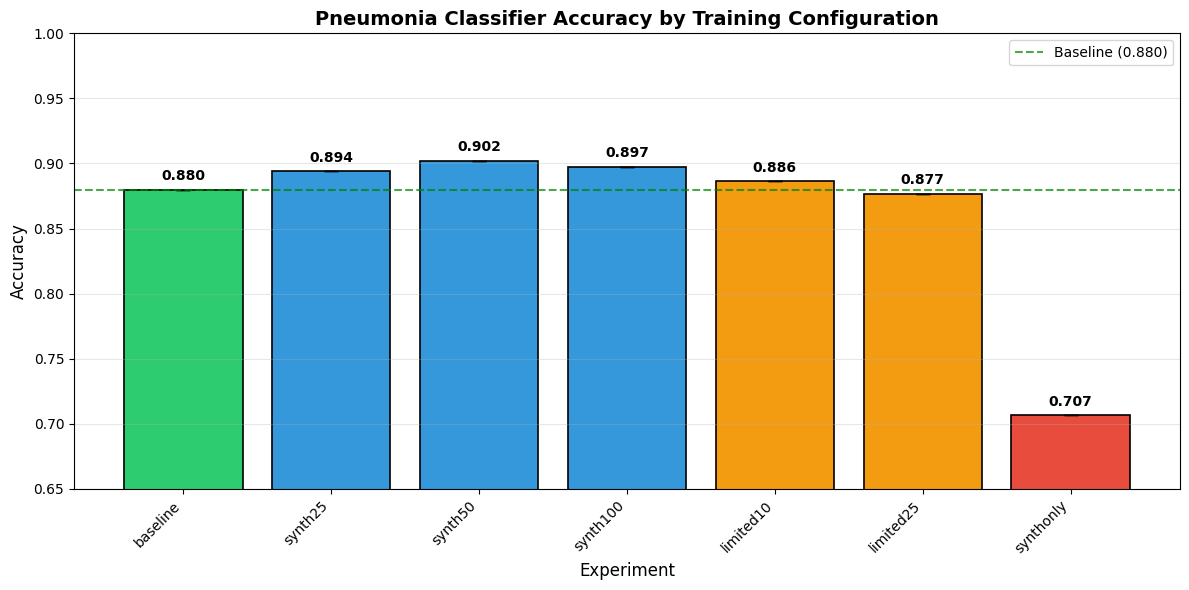

✅ Saved to ./experiment_results/plots/accuracy_comparison.png


In [ ]:
plt.figure(figsize=(12, 6))

experiments = list(all_results.keys())
means = [all_results[exp]['aggregate']['accuracy_mean'] for exp in experiments]
stds = [all_results[exp]['aggregate']['accuracy_std'] for exp in experiments]

# Color coding
colors = []
for exp in experiments:
    if exp == 'baseline':
        colors.append('#2ecc71')  # Green for baseline
    elif exp == 'synthonly':
        colors.append('#e74c3c')  # Red for synth only
    elif 'limited' in exp:
        colors.append('#f39c12')  # Orange for limited
    else:
        colors.append('#3498db')  # Blue for augmentation

bars = plt.bar(experiments, means, yerr=stds, capsize=5, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Experiment', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Pneumonia Classifier Accuracy by Training Configuration', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.65, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add baseline reference line
baseline_mean = all_results['baseline']['aggregate']['accuracy_mean']
plt.axhline(y=baseline_mean, color='green', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_mean:.3f})')
plt.legend()

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/accuracy_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved to {PLOTS_DIR}/accuracy_comparison.png")

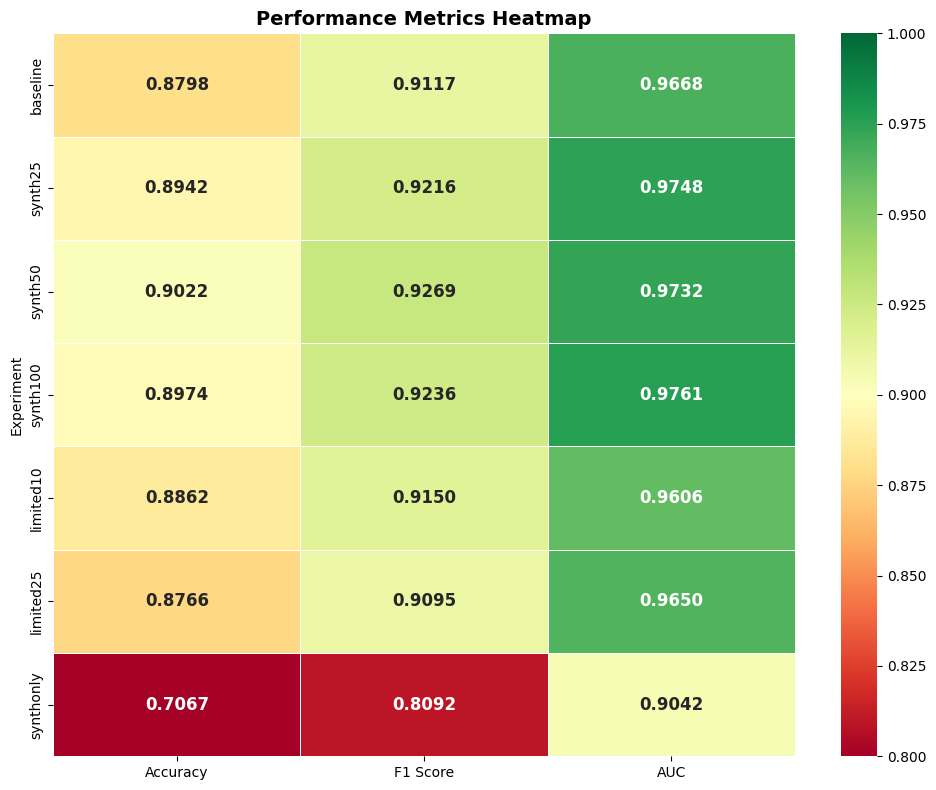

✅ Saved to ./experiment_results/plots/metrics_heatmap.png


In [ ]:
metrics_data = []
for exp_name, data in all_results.items():
    agg = data['aggregate']
    metrics_data.append({
        'Experiment': exp_name,
        'Accuracy': agg['accuracy_mean'],
        'F1 Score': agg['f1_mean'],
        'AUC': agg['auc_mean']
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.set_index('Experiment')

plt.figure(figsize=(10, 8))
sns.heatmap(metrics_df, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0.80, vmax=1.0, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Performance Metrics Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/metrics_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {PLOTS_DIR}/metrics_heatmap.png")

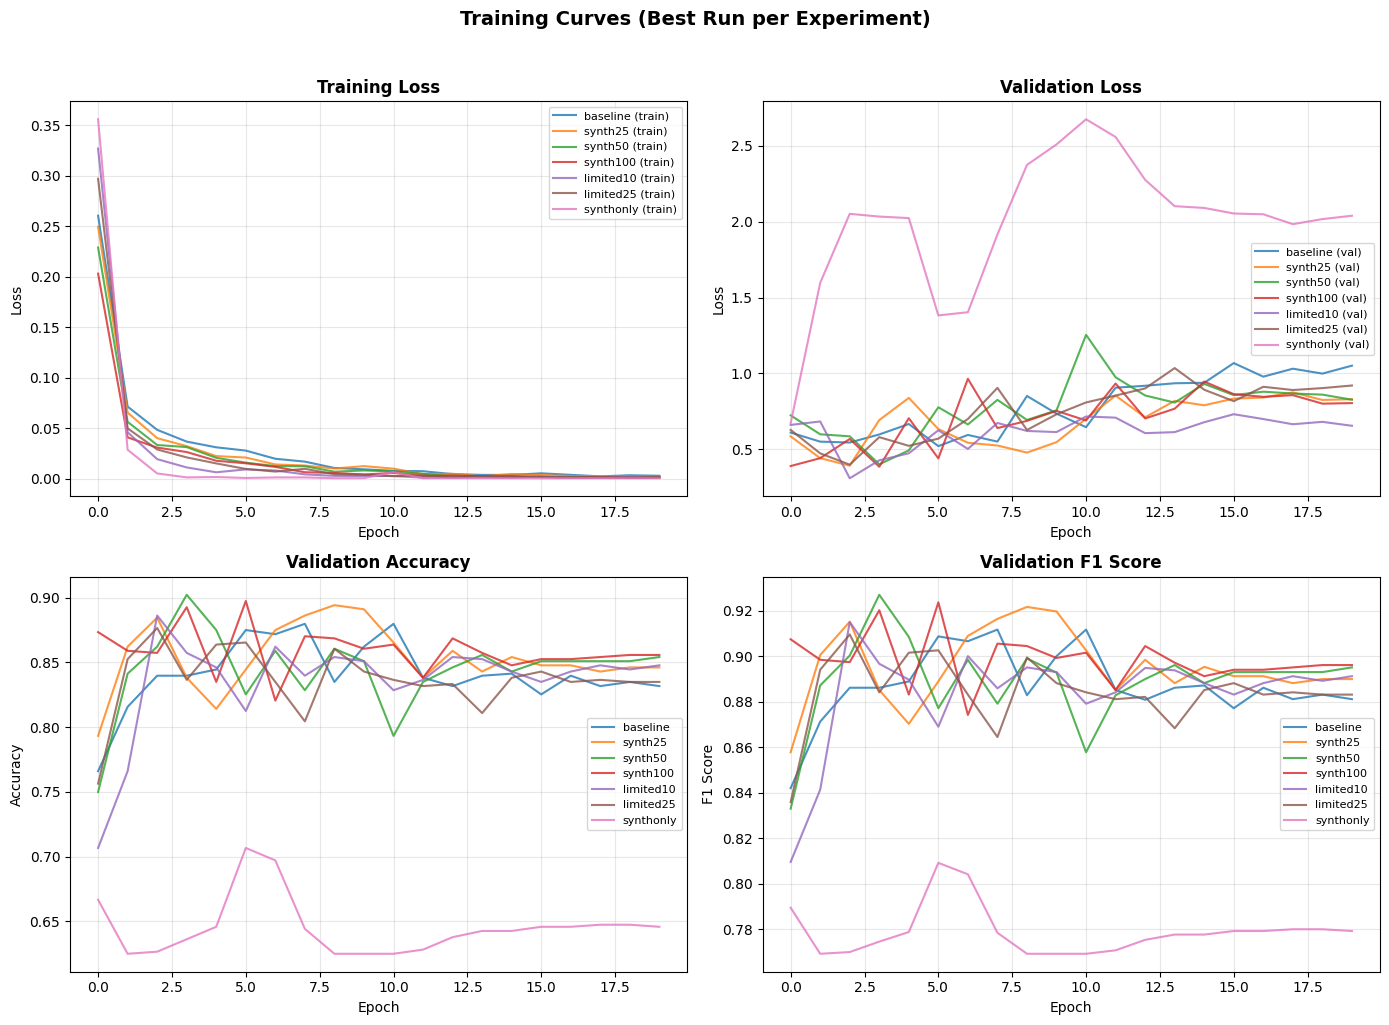

✅ Saved to ./experiment_results/plots/training_curves.png


In [ ]:
# ============================================================
# CELL 21: Generate Visualization - Training Curves (Best Run)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for exp_name, data in all_results.items():
    best_run_idx = data['best_run']
    history = data['runs'][best_run_idx]['history']

    # Loss
    axes[0, 0].plot(history['train_loss'], label=f'{exp_name} (train)', alpha=0.8)
    axes[0, 1].plot(history['val_loss'], label=f'{exp_name} (val)', alpha=0.8)

    # Accuracy and F1
    axes[1, 0].plot(history['val_acc'], label=exp_name, alpha=0.8)
    axes[1, 1].plot(history['val_f1'], label=exp_name, alpha=0.8)

axes[0, 0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].set_title('Validation Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].set_title('Validation Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_title('Validation F1 Score', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Training Curves (Best Run per Experiment)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f" Saved to {PLOTS_DIR}/training_curves.png")

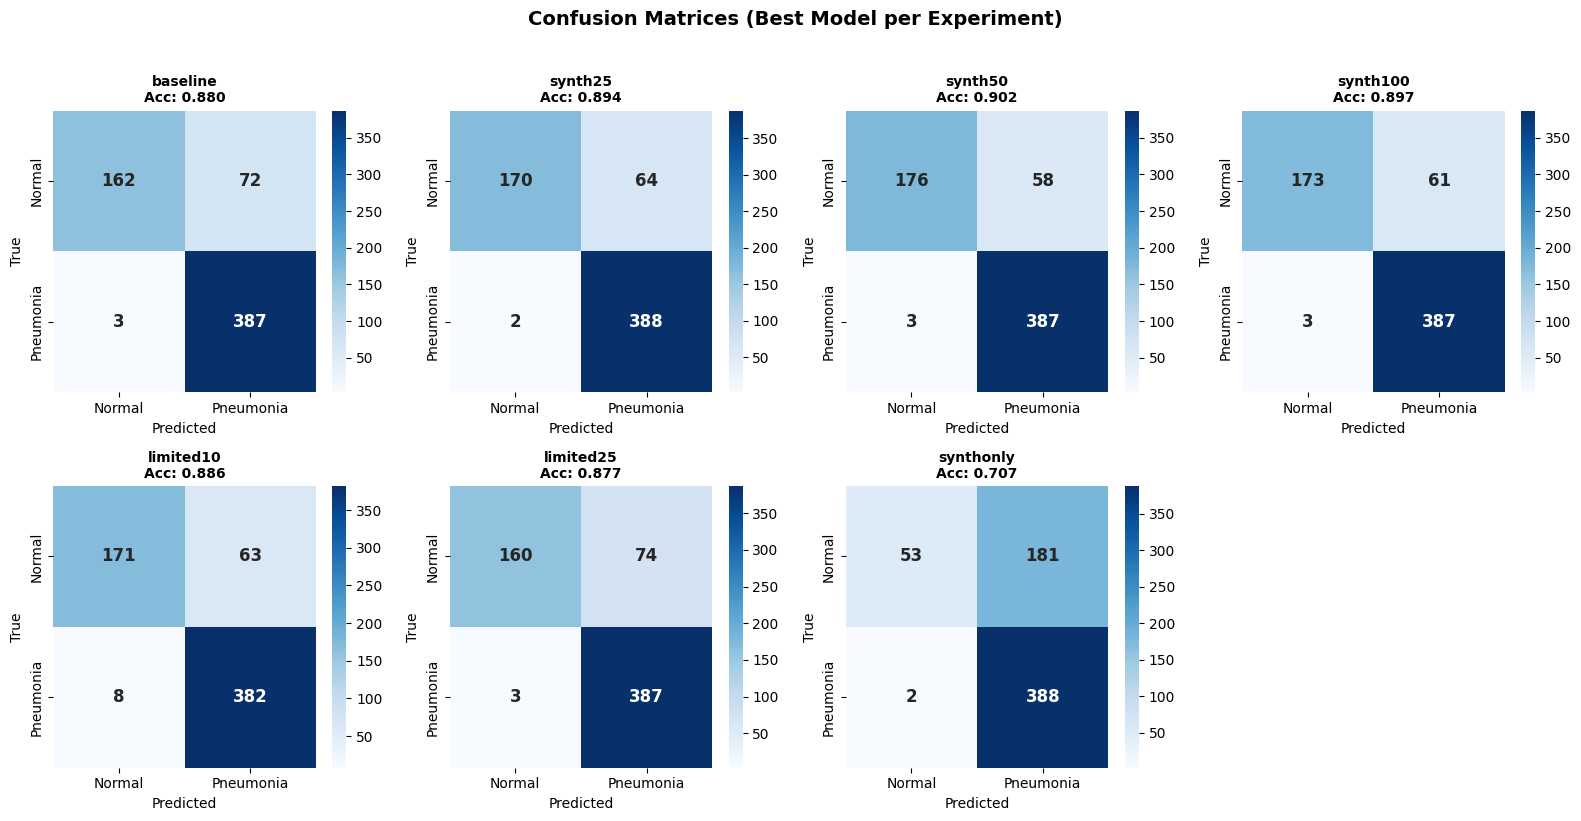

✅ Saved to ./experiment_results/plots/confusion_matrices.png


In [ ]:
# ============================================================
# CELL 22: Generate Confusion Matrices for Best Models
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

class_names = ['Normal', 'Pneumonia']

for idx, (exp_name, data) in enumerate(all_results.items()):
    if idx >= 7:
        break

    best_run_idx = data['best_run']
    cm = np.array(data['runs'][best_run_idx]['eval_metrics']['confusion_matrix'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 12, 'weight': 'bold'})
    axes[idx].set_title(f'{exp_name}\nAcc: {data["best_accuracy"]:.3f}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

# Hide unused subplot
axes[7].axis('off')

plt.suptitle('Confusion Matrices (Best Model per Experiment)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {PLOTS_DIR}/confusion_matrices.png")

In [ ]:
print("\n" + "╔" + "═"*88 + "╗")
print("║" + " "*25 + "FINAL RESULTS SUMMARY" + " "*42 + "║")
print("╠" + "═"*88 + "╣")
print(f"║ {'Experiment':<15} │ {'Accuracy':<18} │ {'F1 Score':<18} │ {'AUC':<18} │ {'Δ Baseline':<12}║")
print("╠" + "═"*88 + "╣")

baseline_acc = all_results['baseline']['aggregate']['accuracy_mean']

for exp_name, data in all_results.items():
    agg = data['aggregate']

    acc_str = f"{agg['accuracy_mean']:.4f} ± {agg['accuracy_std']:.4f}"
    f1_str = f"{agg['f1_mean']:.4f} ± {agg['f1_std']:.4f}"
    auc_str = f"{agg['auc_mean']:.4f} ± {agg['auc_std']:.4f}"

    if exp_name == 'baseline':
        delta_str = "(baseline)"
    else:
        delta = agg['accuracy_mean'] - baseline_acc
        delta_str = f"{delta:+.4f}"

    print(f"║ {exp_name:<15} │ {acc_str:<18} │ {f1_str:<18} │ {auc_str:<18} │ {delta_str:<12}║")

print("╚" + "═"*88 + "╝")


╔════════════════════════════════════════════════════════════════════════════════════════╗
║                         FINAL RESULTS SUMMARY                                          ║
╠════════════════════════════════════════════════════════════════════════════════════════╣
║ Experiment      │ Accuracy           │ F1 Score           │ AUC                │ Δ Baseline  ║
╠════════════════════════════════════════════════════════════════════════════════════════╣
║ baseline        │ 0.8798 ± 0.0000    │ 0.9117 ± 0.0000    │ 0.9668 ± 0.0000    │ (baseline)  ║
║ synth25         │ 0.8942 ± 0.0000    │ 0.9216 ± 0.0000    │ 0.9748 ± 0.0000    │ +0.0144     ║
║ synth50         │ 0.9022 ± 0.0000    │ 0.9269 ± 0.0000    │ 0.9732 ± 0.0000    │ +0.0224     ║
║ synth100        │ 0.8974 ± 0.0000    │ 0.9236 ± 0.0000    │ 0.9761 ± 0.0000    │ +0.0176     ║
║ limited10       │ 0.8862 ± 0.0000    │ 0.9150 ± 0.0000    │ 0.9606 ± 0.0000    │ +0.0064     ║
║ limited25       │ 0.8766 ± 0.0000    │ 0.9095 ± 0.0

In [ ]:
# Create a directory for upload-ready models
UPLOAD_DIR = f"{OUTPUT_DIR}/upload_models"
os.makedirs(UPLOAD_DIR, exist_ok=True)

# Prepare each best model
upload_info = []

for exp_name, data in all_results.items():
    exp_config = EXPERIMENTS[exp_name]

    # Load best checkpoint
    best_model_path = data['best_model_path']
    checkpoint = torch.load(best_model_path, weights_only=False)

    # Create model and load state dict
    model = PneumoniaClassifier(pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Save just the model state dict (cleaner for upload)
    upload_model_path = f"{UPLOAD_DIR}/{exp_name}_model.pth"
    torch.save(model.state_dict(), upload_model_path)

    # Also save config
    config_path = f"{UPLOAD_DIR}/{exp_name}_config.json"
    model_config = {
        'architecture': 'DenseNet-121',
        'num_classes': 2,
        'class_names': ['NORMAL', 'PNEUMONIA'],
        'input_size': 224,
        'experiment': exp_name,
        'description': exp_config['description'],
        'real_ratio': exp_config['real_ratio'],
        'synthetic_ratio': exp_config['synthetic_ratio'],
        'best_accuracy': data['best_accuracy'],
        'metrics': {
            'accuracy_mean': data['aggregate']['accuracy_mean'],
            'accuracy_std': data['aggregate']['accuracy_std'],
            'f1_mean': data['aggregate']['f1_mean'],
            'auc_mean': data['aggregate']['auc_mean']
        },
        'training': {
            'epochs': CONFIG['num_epochs'],
            'batch_size': CONFIG['batch_size'],
            'learning_rate': CONFIG['learning_rate'],
            'optimizer': 'AdamW',
            'scheduler': 'CosineAnnealingLR'
        },
        'datasets': {
            'real': 'hf-vision/chest-xray-pneumonia',
            'synthetic': 'chimbiwide/synthetic-chest-xray-pneumonia'
        }
    }

    with open(config_path, 'w') as f:
        json.dump(model_config, f, indent=2)

    upload_info.append({
        'exp_name': exp_name,
        'hf_repo': exp_config['hf_model_name'],
        'model_path': upload_model_path,
        'config_path': config_path,
        'accuracy': data['best_accuracy']
    })

    print(f"Prepared {exp_name}: {upload_model_path}")

print(f"\n All {len(upload_info)} models prepared for upload")

✅ Prepared baseline: ./experiment_results/upload_models/baseline_model.pth
✅ Prepared synth25: ./experiment_results/upload_models/synth25_model.pth
✅ Prepared synth50: ./experiment_results/upload_models/synth50_model.pth
✅ Prepared synth100: ./experiment_results/upload_models/synth100_model.pth
✅ Prepared limited10: ./experiment_results/upload_models/limited10_model.pth
✅ Prepared limited25: ./experiment_results/upload_models/limited25_model.pth
✅ Prepared synthonly: ./experiment_results/upload_models/synthonly_model.pth

✅ All 7 models prepared for upload


In [ ]:
api = HfApi()

for info in upload_info:
    repo_id = info['hf_repo']

    print(f"\n{'='*60}")
    print(f"Uploading: {repo_id}")
    print(f"{'='*60}")

    try:
        # Create repo (if doesn't exist)
        try:
            create_repo(repo_id, repo_type="model", exist_ok=True)
            print(f"  ✓ Repository created/verified: {repo_id}")
        except Exception as e:
            print(f"  Note: {e}")

        # Upload model file
        api.upload_file(
            path_or_fileobj=info['model_path'],
            path_in_repo="pytorch_model.pth",
            repo_id=repo_id,
            repo_type="model"
        )
        print(f"  ✓ Uploaded: pytorch_model.pth")

        # Upload config file
        api.upload_file(
            path_or_fileobj=info['config_path'],
            path_in_repo="config.json",
            repo_id=repo_id,
            repo_type="model"
        )
        print(f"  ✓ Uploaded: config.json")

        print(f"  ✅ Successfully uploaded to: https://huggingface.co/{repo_id}")

    except Exception as e:
        print(f"  Error uploading {repo_id}: {e}")

print("\n" + "="*60)
print("UPLOAD COMPLETE!")
print("="*60)


Uploading: chimbiwide/pneumonia-densenet-baseline
  ✓ Repository created/verified: chimbiwide/pneumonia-densenet-baseline


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...models/baseline_model.pth:   0%|          | 54.7kB / 30.5MB            

  ✓ Uploaded: pytorch_model.pth
  ✓ Uploaded: config.json
  ✅ Successfully uploaded to: https://huggingface.co/chimbiwide/pneumonia-densenet-baseline

Uploading: chimbiwide/pneumonia-densenet-synth25
  ✓ Repository created/verified: chimbiwide/pneumonia-densenet-synth25


...

  ✓ Uploaded: pytorch_model.pth
  ✓ Uploaded: config.json
  ✅ Successfully uploaded to: https://huggingface.co/chimbiwide/pneumonia-densenet-limited25

Uploading: chimbiwide/pneumonia-densenet-synthonly
  ✓ Repository created/verified: chimbiwide/pneumonia-densenet-synthonly


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...odels/synthonly_model.pth:   0%|          | 54.7kB / 30.5MB            

  ✓ Uploaded: pytorch_model.pth
  ✓ Uploaded: config.json
  ✅ Successfully uploaded to: https://huggingface.co/chimbiwide/pneumonia-densenet-synthonly

UPLOAD COMPLETE!
